# Dhaka Air Quality — Daily-Resolution Analysis

**Companion analysis to the monthly EDA notebook (`main.ipynb`)**  
Exploits the daily-resolution dataset (`data/daily_dhaka_aqi_dataset.csv`) to
produce supplementary figures and statistics that are only meaningful at daily
granularity: threshold exceedance counts, fine-scale COVID impacts, and
within-season variability.

| | |
|---|---|
| **Period** | 2017-01-01 – 2026-05 |
| **Primary source (2020+)** | aqi.in scraped daily AQI |
| **Pollutant concentrations** | CAMS EAC4 reanalysis 2017–2022; monthly means 2023+ |
| **NAQMP reference** | Bangladesh National Air Quality Management Plan 2024–2030 |

---
## Sections
1. Setup & Data Loading
2. Descriptive Statistics (Daily)
3. Daily Time Series & Rolling Trends
4. Seasonal & Monthly Cycle
5. WHO & Bangladesh Standard Exceedances
6. Pollutant Co-variation (CAMS 2017–2022)
7. COVID-19 Lockdown Impact (Daily Resolution)
8. AQI Category Days per Year
9. Socioeconomic Context

In [1]:
import pathlib, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu, kruskal

import sys
sys.path.insert(0, str(pathlib.Path().resolve()))
from src.config import PAL, SEASON_PAL, apply_style
from src.viz import save_fig

from IPython.display import display
apply_style()
FIG_DIR = pathlib.Path('figures')
FIG_DIR.mkdir(exist_ok=True)

# ── WHO / Bangladesh ambient air quality standards ──────────────────────────
# PM2.5: WHO 2021 annual=5, 24-hr=15 µg/m³  |  Bangladesh APCR annual=15, 24-hr=65 µg/m³
# PM10:  WHO 2021 annual=15, 24-hr=45 µg/m³ |  Bangladesh APCR annual=50, 24-hr=150 µg/m³
WHO_PM25_ANNUAL = 5
WHO_PM25_24HR   = 15
BGD_PM25_24HR   = 65
BGD_PM25_ANNUAL = 15
WHO_PM10_24HR   = 45
BGD_PM10_24HR   = 150

# AQI category breakpoints (US EPA)
AQI_CATS = [
    (0,   50,  'Good',             '#00e400'),
    (51,  100, 'Moderate',         '#ffff00'),
    (101, 150, 'Unhealthy for SG', '#ff7e00'),
    (151, 200, 'Unhealthy',        '#ff0000'),
    (201, 300, 'Very Unhealthy',   '#8f3f97'),
    (301, 500, 'Hazardous',        '#7e0023'),
]

def aqi_category(val):
    for lo, hi, cat, _ in AQI_CATS:
        if lo <= val <= hi:
            return cat
    return 'Hazardous'

SEASON_ORDER = ['Winter', 'Pre-monsoon', 'Monsoon', 'Post-monsoon']
MONTH_ABBR   = ['Jan','Feb','Mar','Apr','May','Jun',
                 'Jul','Aug','Sep','Oct','Nov','Dec']

print('Setup complete.')

Setup complete.


---
## § 1 — Data Loading

In [2]:
daily = pd.read_csv('data/daily_dhaka_aqi_dataset.csv', parse_dates=['date'])
daily = daily.sort_values('date').reset_index(drop=True)

monthly = pd.read_csv('data/final_dhaka_aqi_dataset_clean.csv', parse_dates=['month_start'])
monthly = monthly.sort_values('month_start').reset_index(drop=True)

cams = pd.read_csv('data/cams_dhaka_pollutants.csv', parse_dates=['date'])
cams = cams.sort_values('date').reset_index(drop=True)
cams['month']  = cams['date'].dt.month
cams['year']   = cams['date'].dt.year

# Annual socioeconomic summary
annual_socio = monthly.groupby('year').agg(
    population_total = ('population_total', 'first'),
    urban_share_pct  = ('urban_share_pct',  'first'),
    hdi              = ('hdi',              'first'),
    poverty_rate_pct = ('poverty_rate_pct', 'first'),
    aqi_mean         = ('aqi_mean',         'mean'),
    pm25_mean        = ('pm25_mean',        'mean'),
).reset_index()

# Season as ordered categorical
daily['season'] = pd.Categorical(daily['season'], categories=SEASON_ORDER, ordered=True)

# Assign AQI category
daily['aqi_cat'] = daily['aqi'].apply(aqi_category)

# ── Quick coverage summary ───────────────────────────────────────────────────
print(f'Daily rows : {len(daily):,}  ({daily.date.min().date()} → {daily.date.max().date()})')
print(f'Source split: {daily.source.value_counts().to_dict()}')
print()
print('Null counts:')
print(daily.isnull().sum()[daily.isnull().sum() > 0])

Daily rows : 3,407  (2017-01-01 → 2026-05-02)
Source split: {'daily_aqi': 2141, 'monthly_avg': 1266}

Null counts:
pm25     120
pm10     120
no2      120
so2      120
co      1216
o3      1216
dtype: int64


---
## § 2 — Descriptive Statistics (Daily)

In [3]:
cols = ['aqi', 'pm25', 'pm10', 'no2', 'so2', 'co', 'o3']
labels = {'aqi':'AQI', 'pm25':'PM₂.₅ (µg/m³)', 'pm10':'PM₁₀ (µg/m³)',
          'no2':'NO₂ (µg/m³)', 'so2':'SO₂ (µg/m³)', 'co':'CO (µg/m³)', 'o3':'O₃ (µg/m³)'}

rows = []
for col in cols:
    s = daily[col].dropna()
    if len(s) == 0:
        continue
    stat, pval = stats.shapiro(s.sample(min(500, len(s)), random_state=42))
    rows.append(dict(
        Variable  = labels[col],
        n         = len(s),
        Mean      = s.mean(),
        Std       = s.std(),
        Min       = s.min(),
        Q25       = s.quantile(0.25),
        Median    = s.median(),
        Q75       = s.quantile(0.75),
        Max       = s.max(),
        Skewness  = s.skew(),
        Kurtosis  = s.kurt(),
        SW_p      = pval,
        Normal    = 'Yes' if pval > 0.05 else 'No',
    ))

desc = pd.DataFrame(rows).set_index('Variable')
desc_fmt = desc.copy()
for c in ['Mean','Std','Min','Q25','Median','Q75','Max','Skewness','Kurtosis']:
    desc_fmt[c] = desc_fmt[c].map('{:.1f}'.format)
desc_fmt['SW_p'] = desc['SW_p'].map('{:.4f}'.format)
print('Daily Descriptive Statistics (2017–2026)')
display(desc_fmt)

Daily Descriptive Statistics (2017–2026)


,n,Mean,Std,Min,Q25,Median,Q75,Max,Skewness,Kurtosis,SW_p,Normal
Variable,,,,,,,,,,,,
AQI,3407,164.4,56.0,19.0,122.0,182.5,191.4,376.0,-0.2,-0.4,0.0000,No
PM₂.₅ (µg/m³),3287,90.0,65.8,11.8,38.8,66.0,128.2,340.7,1.0,0.2,0.0000,No
PM₁₀ (µg/m³),3287,191.2,118.8,21.4,91.9,159.7,287.0,479.9,0.5,-0.9,0.0000,No
NO₂ (µg/m³),3287,33.5,21.3,4.8,17.7,27.3,42.6,98.4,1.1,0.1,0.0000,No
SO₂ (µg/m³),3287,27.8,23.9,2.5,8.0,21.1,31.8,88.0,1.1,0.2,0.0000,No
CO (µg/m³),2191,984.5,759.1,133.4,305.9,737.4,1570.2,3435.7,0.7,-0.6,0.0000,No
O₃ (µg/m³),2191,58.7,14.9,20.3,48.4,56.8,67.4,118.3,0.5,0.3,0.0000,No


---
## § 3 — Daily Time Series & Rolling Trends (Figure 1)

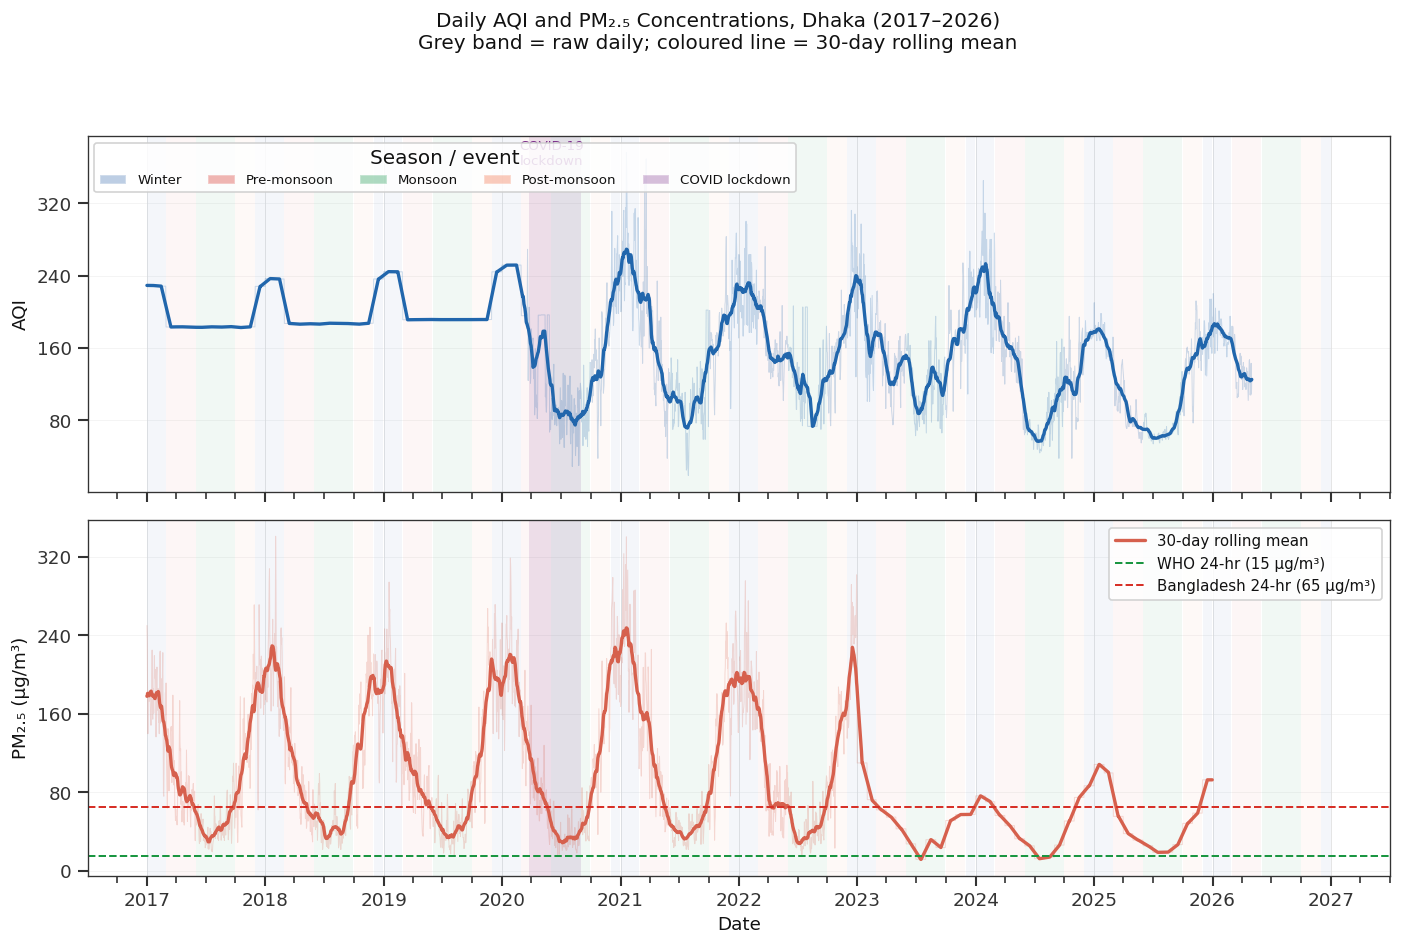

Saved → figures/analysis_fig01_daily_time_series.png


In [4]:
# ── Figure 1: Daily AQI + PM2.5 with 30-day rolling mean ────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.subplots_adjust(hspace=0.08)

SEASON_SHADE = {
    'Winter':       ('#4475b4', 0.06),
    'Pre-monsoon':  ('#d73027', 0.04),
    'Monsoon':      ('#1a9850', 0.06),
    'Post-monsoon': ('#f46d43', 0.04),
}

for ax, col, label, color in zip(
    axes,
    ['aqi',  'pm25'],
    ['AQI',  'PM₂.₅ (µg/m³)'],
    ['#2166ac', '#d6604d'],
):
    d = daily.set_index('date')[col].dropna()
    roll = d.rolling(30, center=True, min_periods=15).mean()

    # Season shading
    for yr in range(2017, 2027):
        shade_ranges = {
            'Winter':       [(f'{yr}-01-01', f'{yr}-02-28'), (f'{yr}-12-01', f'{yr}-12-31')],
            'Pre-monsoon':  [(f'{yr}-03-01', f'{yr}-05-31')],
            'Monsoon':      [(f'{yr}-06-01', f'{yr}-09-30')],
            'Post-monsoon': [(f'{yr}-10-01', f'{yr}-11-30')],
        }
        for season, ranges in shade_ranges.items():
            c, alpha = SEASON_SHADE[season]
            for (s, e) in ranges:
                try:
                    ax.axvspan(pd.Timestamp(s), pd.Timestamp(e),
                               color=c, alpha=alpha, linewidth=0)
                except Exception:
                    pass

    # COVID lockdown shading
    ax.axvspan(pd.Timestamp('2020-03-26'), pd.Timestamp('2020-08-31'),
               color='#7b2d8b', alpha=0.12, linewidth=0)

    # Raw values
    ax.plot(d.index, d.values, color=color, alpha=0.22, linewidth=0.6)
    # Rolling mean
    ax.plot(roll.index, roll.values, color=color, linewidth=2.0,
            label='30-day rolling mean')

    # WHO/Bangladesh reference lines for PM2.5
    if col == 'pm25':
        ax.axhline(WHO_PM25_24HR, color='#1a9641', linestyle='--', linewidth=1.2,
                   label=f'WHO 24-hr ({WHO_PM25_24HR} µg/m³)')
        ax.axhline(BGD_PM25_24HR, color='#d73027', linestyle='--', linewidth=1.2,
                   label=f'Bangladesh 24-hr ({BGD_PM25_24HR} µg/m³)')

    ax.set_ylabel(label, fontsize=11)
    ax.yaxis.set_major_locator(mticker.MaxNLocator(6))
    ax.legend(loc='upper right', fontsize=9, framealpha=0.85)
    ax.grid(axis='y', linewidth=0.4, alpha=0.5)

# x-axis
axes[1].xaxis.set_major_locator(mdates.YearLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[1].xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[4, 7, 10]))
axes[1].set_xlabel('Date', fontsize=11)

# COVID annotation
axes[0].annotate('COVID-19\nlockdown', xy=(pd.Timestamp('2020-06-01'), axes[0].get_ylim()[1]*0.92),
                 fontsize=8, color='#7b2d8b', ha='center')

# Season legend
handles = [mpatches.Patch(facecolor=c, alpha=0.35, label=s)
           for s, (c, _) in SEASON_SHADE.items()]
handles.append(mpatches.Patch(facecolor='#7b2d8b', alpha=0.3, label='COVID lockdown'))
axes[0].legend(handles=handles, loc='upper left', fontsize=8, ncol=5,
               framealpha=0.85, title='Season / event')

fig.suptitle('Daily AQI and PM₂.₅ Concentrations, Dhaka (2017–2026)\n'
             'Grey band = raw daily; coloured line = 30-day rolling mean',
             fontsize=12, y=1.01)

display(fig)
save_fig(fig, 'analysis_fig01_daily_time_series')
plt.close(fig)


---
## § 4 — Seasonal & Monthly Cycle (Figures 2–3)

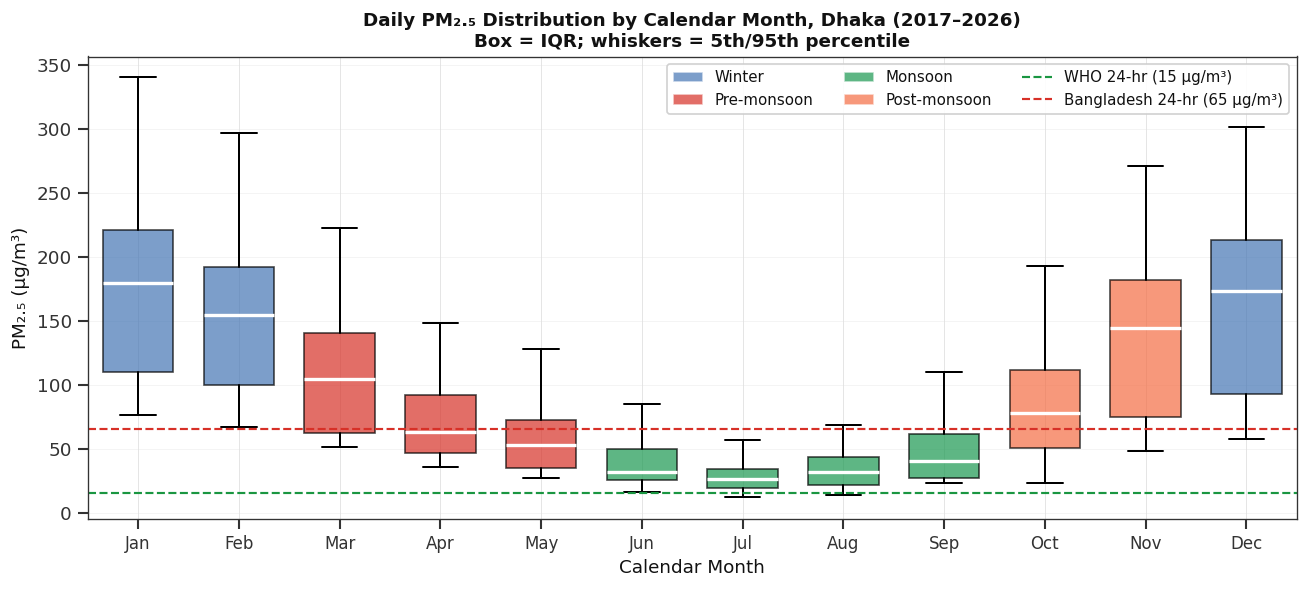

Saved → figures/analysis_fig02_monthly_pm25_boxplot.png


In [5]:
# ── Figure 2: Daily PM2.5 box plots by calendar month ───────────────────────
fig, ax = plt.subplots(figsize=(13, 5))

d = daily[daily['pm25'].notna()].copy()
d['month_int'] = d['date'].dt.month

month_season = {1:'Winter',2:'Winter',3:'Pre-monsoon',4:'Pre-monsoon',5:'Pre-monsoon',
                6:'Monsoon',7:'Monsoon',8:'Monsoon',9:'Monsoon',
                10:'Post-monsoon',11:'Post-monsoon',12:'Winter'}
season_colors = {'Winter':'#4475b4','Pre-monsoon':'#d73027',
                 'Monsoon':'#1a9850','Post-monsoon':'#f46d43'}

positions = list(range(1, 13))
data_by_month = [d[d['month_int'] == m]['pm25'].values for m in positions]
bp = ax.boxplot(data_by_month, positions=positions, widths=0.7,
                patch_artist=True, showfliers=False,
                medianprops=dict(color='white', linewidth=2),
                whiskerprops=dict(linewidth=1.2),
                capprops=dict(linewidth=1.2))

for patch, m in zip(bp['boxes'], positions):
    season = month_season[m]
    patch.set_facecolor(season_colors[season])
    patch.set_alpha(0.7)

ax.axhline(WHO_PM25_24HR, color='#1a9641', linestyle='--', linewidth=1.3,
           label=f'WHO 24-hr guideline ({WHO_PM25_24HR} µg/m³)')
ax.axhline(BGD_PM25_24HR, color='#d73027', linestyle='--', linewidth=1.3,
           label=f'Bangladesh APCR standard ({BGD_PM25_24HR} µg/m³)')

ax.set_xticks(positions)
ax.set_xticklabels(MONTH_ABBR, fontsize=10)
ax.set_xlabel('Calendar Month', fontsize=11)
ax.set_ylabel('PM₂.₅ (µg/m³)', fontsize=11)
ax.set_title('Daily PM₂.₅ Distribution by Calendar Month, Dhaka (2017–2026)\n'
             'Box = IQR; whiskers = 5th/95th percentile', fontsize=11)

legend_handles = [mpatches.Patch(facecolor=c, alpha=0.7, label=s)
                  for s, c in season_colors.items()]
ax.legend(handles=legend_handles +
          [plt.Line2D([0],[0], color='#1a9641', linestyle='--', linewidth=1.3,
                      label=f'WHO 24-hr ({WHO_PM25_24HR} µg/m³)'),
           plt.Line2D([0],[0], color='#d73027', linestyle='--', linewidth=1.3,
                      label=f'Bangladesh 24-hr ({BGD_PM25_24HR} µg/m³)')],
          fontsize=9, ncol=3, loc='upper right')

ax.grid(axis='y', linewidth=0.4, alpha=0.5)
display(fig)
save_fig(fig, 'analysis_fig02_monthly_pm25_boxplot')
plt.close(fig)


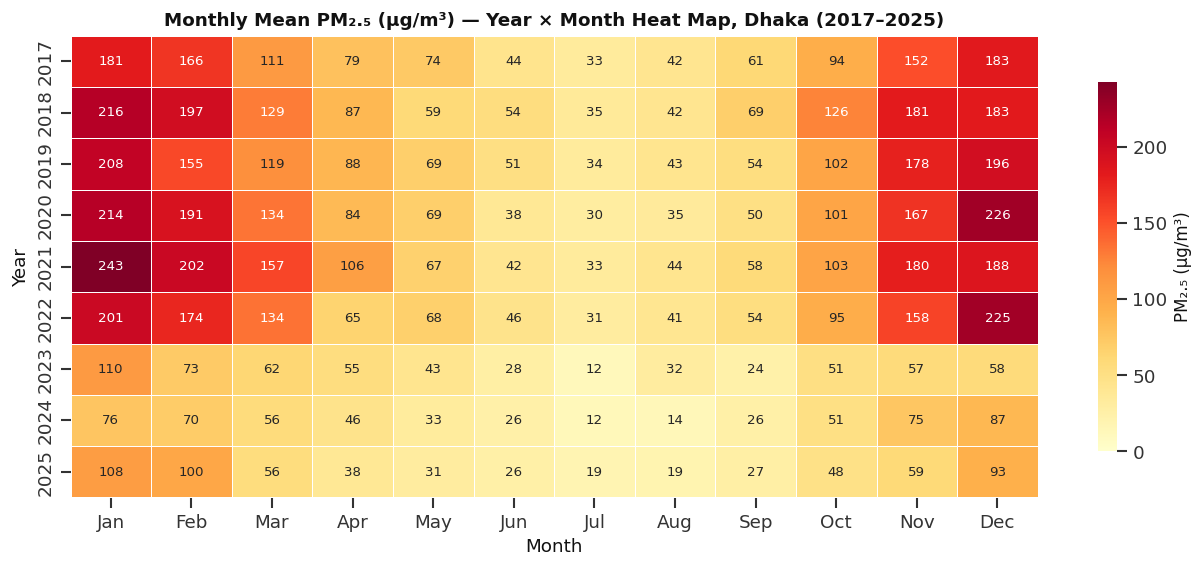

Saved → figures/analysis_fig03_pm25_heatmap.png


In [6]:
# ── Figure 3: Year × Month AQI heatmap (daily data → monthly mean) ───────────
fig, ax = plt.subplots(figsize=(13, 5))

d = daily.copy()
d['month_int'] = d['date'].dt.month
pivot = d.pivot_table(values='pm25', index='year', columns='month_int',
                       aggfunc='mean')
pivot.columns = MONTH_ABBR

# Only show 2017-2025 (2026 is partial)
pivot = pivot.loc[pivot.index <= 2025]

sns.heatmap(pivot, ax=ax, cmap='YlOrRd', annot=True, fmt='.0f',
            annot_kws={'size': 8}, linewidths=0.3,
            cbar_kws={'label': 'PM₂.₅ (µg/m³)', 'shrink': 0.8},
            vmin=0, vmax=pivot.values.max())

ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Year',  fontsize=11)
ax.set_title('Monthly Mean PM₂.₅ (µg/m³) — Year × Month Heat Map, Dhaka (2017–2025)',
             fontsize=11)

display(fig)
save_fig(fig, 'analysis_fig03_pm25_heatmap')
plt.close(fig)


---
## § 5 — WHO & Bangladesh Standard Exceedances (Figures 4–5)

Bangladesh NAQMP 2024–2030 targets a 15 µg/m³ **annual mean** PM₂.₅ reduction  
nationwide and a 30 µg/m³ reduction in the Greater Dhaka Area.  
The WHO 2021 interim guideline is **15 µg/m³ for 24-hour mean** and **5 µg/m³ annual mean**.

In [7]:
# ── Days per year exceeding PM2.5 thresholds ─────────────────────────────────
thresholds = {
    f'> WHO 24-hr ({WHO_PM25_24HR})':        WHO_PM25_24HR,
    f'> Bangladesh 24-hr ({BGD_PM25_24HR})': BGD_PM25_24HR,
    '> Severe (150 µg/m³)':                  150,
    '> Hazardous (250 µg/m³)':               250,
}

pm25_daily = daily[daily['pm25'].notna() & (daily['year'] <= 2025)].copy()
exc_rows = []
for yr, grp in pm25_daily.groupby('year'):
    n_total = len(grp)
    row = {'year': yr, 'total_days': n_total}
    for label, thresh in thresholds.items():
        n_exc = (grp['pm25'] > thresh).sum()
        row[label] = n_exc
        row[f'{label}_pct'] = n_exc / n_total * 100
    exc_rows.append(row)

exc_df = pd.DataFrame(exc_rows)
print('Days per year exceeding PM₂.₅ thresholds:')
display(exc_df[['year'] + list(thresholds.keys())].to_string(index=False))

Days per year exceeding PM₂.₅ thresholds:


' year  > WHO 24-hr (15)  > Bangladesh 24-hr (65)  > Severe (150 µg/m³)  > Hazardous (250 µg/m³)\n 2017               365                      223                    96                        2\n 2018               365                      238                   122                        7\n 2019               365                      240                   102                        7\n 2020               366                      229                   116                       15\n 2021               365                      229                   126                       22\n 2022               365                      226                   112                       14\n 2023               334                       59                     0                        0\n 2024               304                      121                     0                        0\n 2025               365                       90                     0                        0'

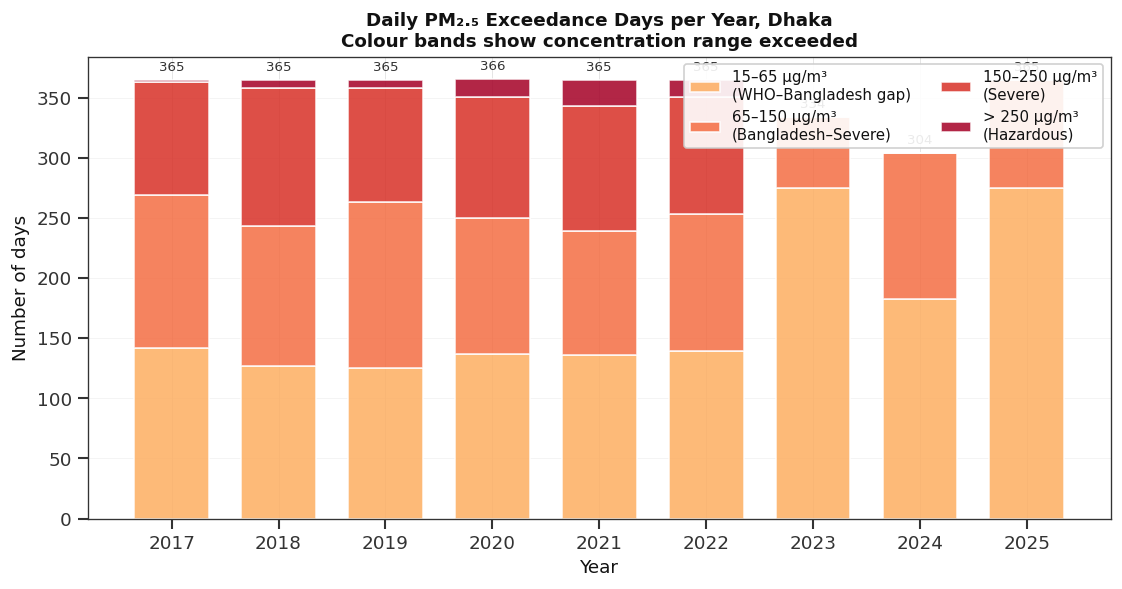

Saved → figures/analysis_fig04_pm25_exceedance.png


In [8]:
# ── Figure 4: Stacked exceedance bar chart ───────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))

years = exc_df['year'].values
t1 = list(thresholds.keys())[0]   # WHO 24-hr
t2 = list(thresholds.keys())[1]   # Bangladesh 24-hr
t3 = list(thresholds.keys())[2]   # Severe
t4 = list(thresholds.keys())[3]   # Hazardous

bar_colors = ['#fdae61', '#f46d43', '#d73027', '#a50026']
bottoms = np.zeros(len(years))

# Use incremental bands: WHO to BGD, BGD to 150, 150 to 250, 250+
bands = [
    (WHO_PM25_24HR, BGD_PM25_24HR, f'{WHO_PM25_24HR}–{BGD_PM25_24HR} µg/m³\n(WHO–Bangladesh gap)', '#fdae61'),
    (BGD_PM25_24HR, 150,            f'{BGD_PM25_24HR}–150 µg/m³\n(Bangladesh–Severe)',                '#f46d43'),
    (150,           250,            '150–250 µg/m³\n(Severe)',                                         '#d73027'),
    (250,           9999,           '> 250 µg/m³\n(Hazardous)',                                        '#a50026'),
]

for lo, hi, band_label, color in bands:
    vals = pm25_daily.groupby('year').apply(
        lambda g: ((g['pm25'] > lo) & (g['pm25'] <= hi)).sum()
    ).reindex(years).fillna(0).values
    ax.bar(years, vals, bottom=bottoms, color=color, alpha=0.85, label=band_label, width=0.7)
    bottoms += vals

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Number of days', fontsize=11)
ax.set_title('Daily PM₂.₅ Exceedance Days per Year, Dhaka\n'
             'Colour bands show concentration range exceeded', fontsize=11)
ax.set_xticks(years)
ax.legend(fontsize=9, ncol=2, loc='upper right')
ax.grid(axis='y', linewidth=0.4, alpha=0.5)

# Annotate total WHO-exceedance days
for yr, tot in zip(years, exc_df[t1].values):
    ax.text(yr, tot + 5, str(int(tot)), ha='center', va='bottom', fontsize=8, color='#333')

display(fig)
save_fig(fig, 'analysis_fig04_pm25_exceedance')
plt.close(fig)


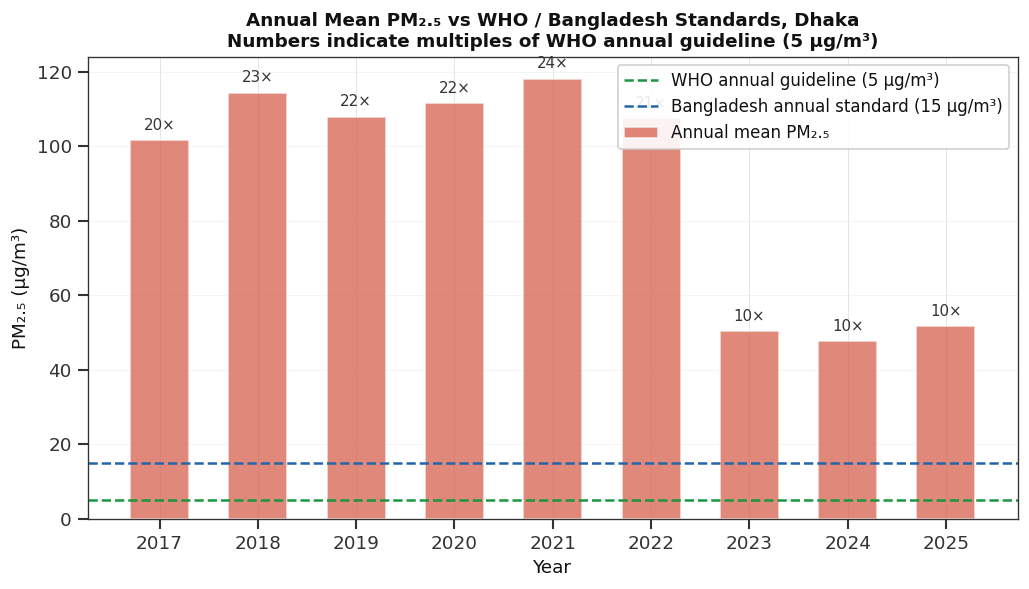

Saved → figures/analysis_fig05_annual_pm25_vs_standards.png


In [9]:
# ── Figure 5: Annual mean PM2.5 vs WHO & Bangladesh annual standards ──────────
fig, ax = plt.subplots(figsize=(10, 5))

annual_pm25 = pm25_daily.groupby('year')['pm25'].mean()

bars = ax.bar(annual_pm25.index, annual_pm25.values, color='#d6604d', alpha=0.75, width=0.6,
              label='Annual mean PM₂.₅')

ax.axhline(WHO_PM25_ANNUAL, color='#1a9641', linestyle='--', linewidth=1.5,
           label=f'WHO annual guideline ({WHO_PM25_ANNUAL} µg/m³)')
ax.axhline(BGD_PM25_ANNUAL, color='#2166ac', linestyle='--', linewidth=1.5,
           label=f'Bangladesh annual standard ({BGD_PM25_ANNUAL} µg/m³)')

for bar, val in zip(bars, annual_pm25.values):
    mult_who = val / WHO_PM25_ANNUAL
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f'{mult_who:.0f}×', ha='center', va='bottom', fontsize=9, color='#333')

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('PM₂.₅ (µg/m³)', fontsize=11)
ax.set_title('Annual Mean PM₂.₅ vs WHO / Bangladesh Standards, Dhaka\n'
             'Numbers indicate multiples of WHO annual guideline (5 µg/m³)', fontsize=11)
ax.set_xticks(annual_pm25.index)
ax.legend(fontsize=10)
ax.grid(axis='y', linewidth=0.4, alpha=0.5)

display(fig)
save_fig(fig, 'analysis_fig05_annual_pm25_vs_standards')
plt.close(fig)


---
## § 6 — Pollutant Co-variation — CAMS 2017–2022 (Figures 6–7)

CAMS EAC4 reanalysis provides daily concentrations for all six pollutants 2017–2022.
This period is used for inter-pollutant correlation and seasonal cycling of gaseous species.

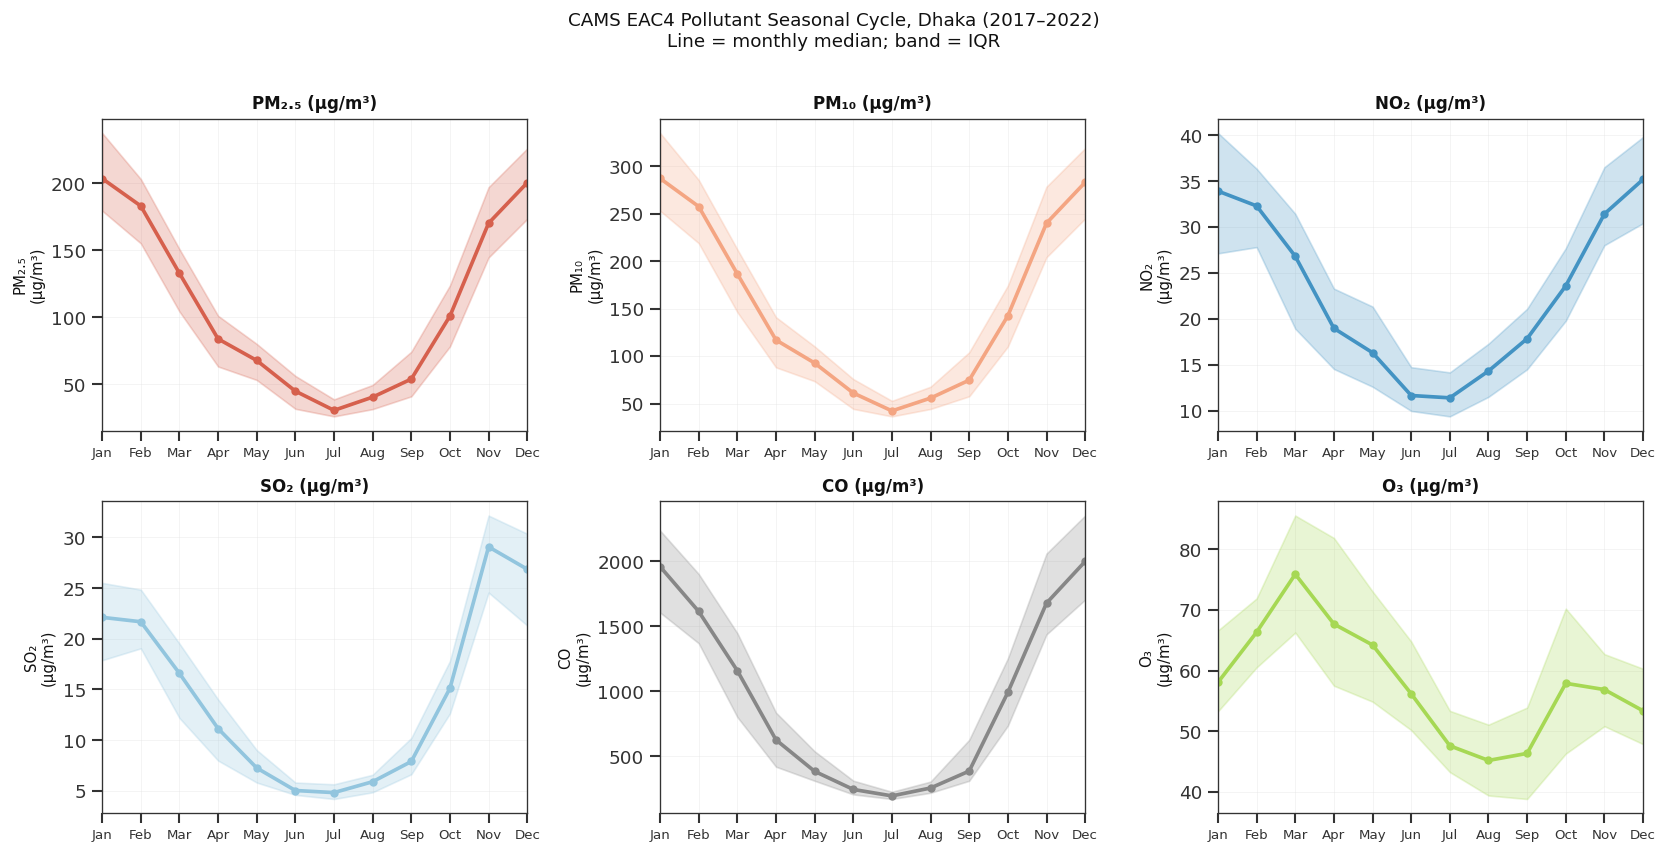

Saved → figures/analysis_fig06_cams_seasonal_cycle.png


In [10]:
# ── Figure 6: CAMS pollutant seasonal cycle (monthly medians) ────────────────
cams_long = cams.copy()
cams_long['season'] = pd.Categorical(
    cams_long['month'].map({
        1:'Winter',2:'Winter',3:'Pre-monsoon',4:'Pre-monsoon',5:'Pre-monsoon',
        6:'Monsoon',7:'Monsoon',8:'Monsoon',9:'Monsoon',
        10:'Post-monsoon',11:'Post-monsoon',12:'Winter'
    }), categories=SEASON_ORDER, ordered=True
)

pol_cams  = ['pm25', 'pm10', 'no2', 'so2', 'co', 'o3']
pol_units = ['PM₂.₅\n(µg/m³)', 'PM₁₀\n(µg/m³)', 'NO₂\n(µg/m³)',
             'SO₂\n(µg/m³)', 'CO\n(µg/m³)', 'O₃\n(µg/m³)']
pol_colors = ['#d6604d','#f4a582','#4393c3','#92c5de','#878787','#a6d854']

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.ravel()

for ax, col, unit, color in zip(axes, pol_cams, pol_units, pol_colors):
    monthly_med = cams_long.groupby('month')[col].agg(['median', lambda x: x.quantile(0.25),
                                                        lambda x: x.quantile(0.75)])
    monthly_med.columns = ['median', 'q25', 'q75']
    months = monthly_med.index

    ax.fill_between(months, monthly_med['q25'], monthly_med['q75'],
                    color=color, alpha=0.25)
    ax.plot(months, monthly_med['median'], color=color, linewidth=2.2,
            marker='o', markersize=4)

    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(MONTH_ABBR, fontsize=8)
    ax.set_ylabel(unit, fontsize=9)
    ax.set_title(unit.replace('\n',' '), fontsize=10)
    ax.grid(linewidth=0.4, alpha=0.5)
    ax.set_xlim(1, 12)

fig.suptitle('CAMS EAC4 Pollutant Seasonal Cycle, Dhaka (2017–2022)\n'
             'Line = monthly median; band = IQR', fontsize=11, y=1.01)
plt.tight_layout()
display(fig)
save_fig(fig, 'analysis_fig06_cams_seasonal_cycle')
plt.close(fig)


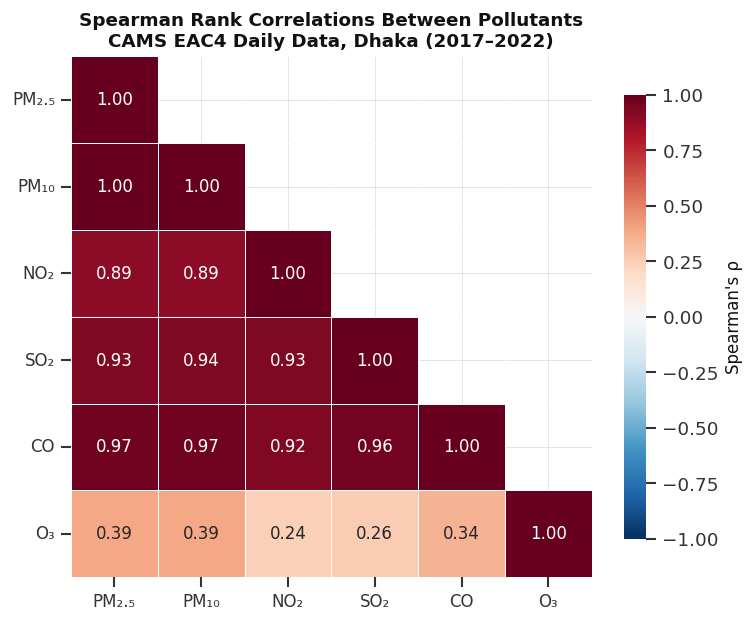

Saved → figures/analysis_fig07_pollutant_correlation.png


In [11]:
# ── Figure 7: Pollutant correlation matrix (CAMS daily 2017–2022) ─────────────
from scipy.stats import spearmanr

cams_clean = cams[pol_cams].dropna()

corr_matrix = pd.DataFrame(
    [[spearmanr(cams_clean[c1], cams_clean[c2]).statistic
      for c2 in pol_cams] for c1 in pol_cams],
    index=pol_cams, columns=pol_cams
)

fig, ax = plt.subplots(figsize=(7, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, ax=ax, mask=mask,
            cmap='RdBu_r', vmin=-1, vmax=1, center=0,
            annot=True, fmt='.2f', annot_kws={'size': 10},
            square=True, linewidths=0.5,
            cbar_kws={'label': "Spearman's ρ", 'shrink': 0.8})

labels = ['PM₂.₅','PM₁₀','NO₂','SO₂','CO','O₃']
ax.set_xticklabels(labels, fontsize=10)
ax.set_yticklabels(labels, fontsize=10, rotation=0)
ax.set_title("Spearman Rank Correlations Between Pollutants\n"
             "CAMS EAC4 Daily Data, Dhaka (2017–2022)", fontsize=11)

display(fig)
save_fig(fig, 'analysis_fig07_pollutant_correlation')
plt.close(fig)


---
## § 7 — COVID-19 Lockdown Impact at Daily Resolution (Figure 8)

Bangladesh imposed a nationwide lockdown on **26 March 2020**, with restrictions
gradually easing from June and fully lifted by end of August 2020.  
Daily data allows us to pinpoint the onset and recovery of the pollution dip
with far greater precision than monthly averages.

In [12]:
# ── COVID lockdown daily analysis ─────────────────────────────────────────────
LOCKDOWN_START = pd.Timestamp('2020-03-26')
LOCKDOWN_END   = pd.Timestamp('2020-08-31')

# 90-day window either side of lockdown
window_start = LOCKDOWN_START - pd.Timedelta(days=90)
window_end   = LOCKDOWN_END   + pd.Timedelta(days=90)

covid_window = daily[(daily['date'] >= window_start) &
                     (daily['date'] <= window_end)].copy()

# Pre / Lockdown / Post
pre_days  = daily[(daily['date'] >= '2019-01-01') & (daily['date'] < LOCKDOWN_START)]
lock_days = daily[(daily['date'] >= LOCKDOWN_START) & (daily['date'] <= LOCKDOWN_END)]
post_days = daily[(daily['date'] > LOCKDOWN_END) & (daily['date'] <= '2022-12-31')]

print('COVID analysis — PM₂.₅ (µg/m³):')
print(f'  Pre-lockdown  (2019–Mar2020): mean={pre_days["pm25"].mean():.1f}, median={pre_days["pm25"].median():.1f}')
print(f'  Lockdown      (Mar–Aug 2020): mean={lock_days["pm25"].mean():.1f}, median={lock_days["pm25"].median():.1f}')
print(f'  Post-lockdown (Sep2020–2022): mean={post_days["pm25"].mean():.1f}, median={post_days["pm25"].median():.1f}')
stat, pval = mannwhitneyu(pre_days['pm25'].dropna(), lock_days['pm25'].dropna(), alternative='greater')
print(f'  Mann-Whitney U (pre > lock): p = {pval:.4f}')

COVID analysis — PM₂.₅ (µg/m³):
  Pre-lockdown  (2019–Mar2020): mean=122.3, median=112.4
  Lockdown      (Mar–Aug 2020): mean=53.6, median=43.4
  Post-lockdown (Sep2020–2022): mean=116.2, median=98.6
  Mann-Whitney U (pre > lock): p = 0.0000


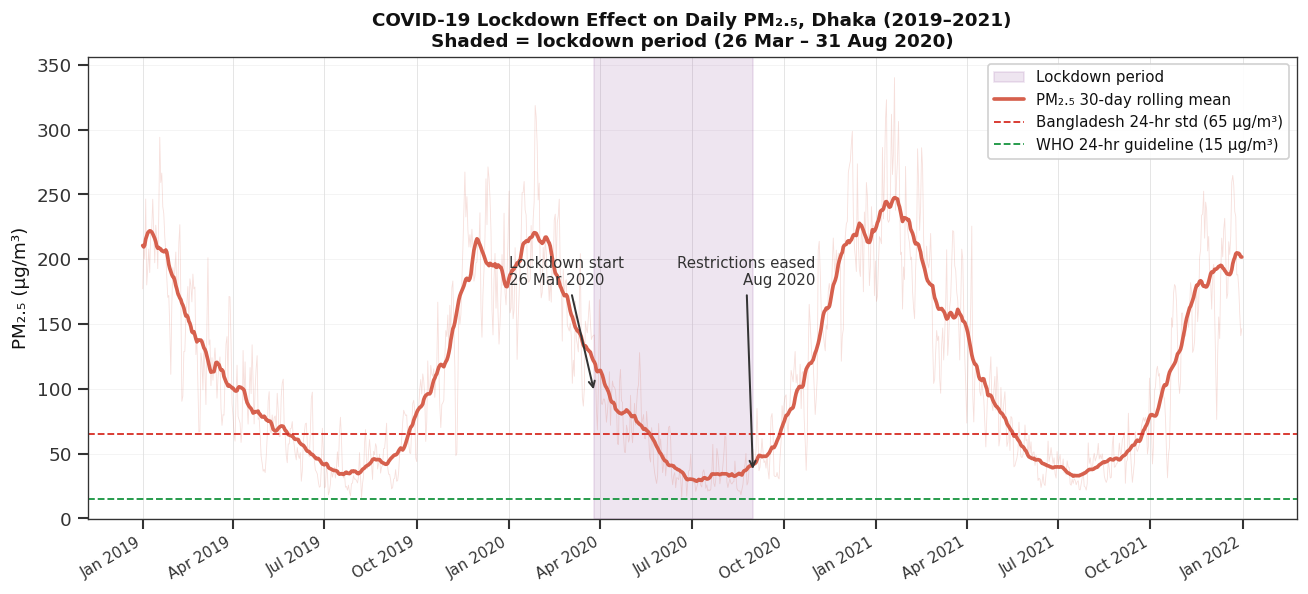

Saved → figures/analysis_fig08_covid_daily.png


In [13]:
# ── Figure 8: COVID daily PM2.5 around lockdown ──────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))

d_covid = daily[(daily['date'] >= '2019-01-01') &
                (daily['date'] <= '2021-12-31') &
                daily['pm25'].notna()].set_index('date')

roll = d_covid['pm25'].rolling(30, center=True, min_periods=10).mean()

# Shade lockdown
ax.axvspan(LOCKDOWN_START, LOCKDOWN_END, color='#7b2d8b', alpha=0.12, label='Lockdown period')

# Same-month 2019 baseline reference band
monthly_2019 = daily[(daily['year'] == 2019) & daily['pm25'].notna()].copy()
monthly_2019_med = monthly_2019.groupby('month')['pm25'].agg(['mean','std'])

# Raw
ax.plot(d_covid.index, d_covid['pm25'], color='#d6604d', alpha=0.2, linewidth=0.5)
# Rolling mean
ax.plot(roll.index, roll.values, color='#d6604d', linewidth=2.2, label='PM₂.₅ 30-day rolling mean')

# Reference lines
ax.axhline(BGD_PM25_24HR, color='#d73027', linestyle='--', linewidth=1.1,
           label=f'Bangladesh 24-hr std ({BGD_PM25_24HR} µg/m³)')
ax.axhline(WHO_PM25_24HR,  color='#1a9641', linestyle='--', linewidth=1.1,
           label=f'WHO 24-hr guideline ({WHO_PM25_24HR} µg/m³)')

# Annotate lockdown
ax.annotate('Lockdown start\n26 Mar 2020',
            xy=(LOCKDOWN_START, roll.loc[LOCKDOWN_START:LOCKDOWN_START + pd.Timedelta(30,'d')].mean()),
            xytext=(pd.Timestamp('2020-01-01'), 180),
            arrowprops=dict(arrowstyle='->', color='#333', lw=1.2),
            fontsize=9, color='#333')
ax.annotate('Restrictions eased\nAug 2020',
            xy=(LOCKDOWN_END, roll.loc[LOCKDOWN_END - pd.Timedelta(30,'d'):LOCKDOWN_END].mean()),
            xytext=(pd.Timestamp('2020-11-01'), 180),
            arrowprops=dict(arrowstyle='->', color='#333', lw=1.2),
            fontsize=9, color='#333', ha='right')

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=9)

ax.set_ylabel('PM₂.₅ (µg/m³)', fontsize=11)
ax.set_title('COVID-19 Lockdown Effect on Daily PM₂.₅, Dhaka (2019–2021)\n'
             'Shaded = lockdown period (26 Mar – 31 Aug 2020)', fontsize=11)
ax.legend(fontsize=9, loc='upper right')
ax.grid(axis='y', linewidth=0.4, alpha=0.5)

display(fig)
save_fig(fig, 'analysis_fig08_covid_daily')
plt.close(fig)


---
## § 8 — AQI Category Days per Year (Figure 9)

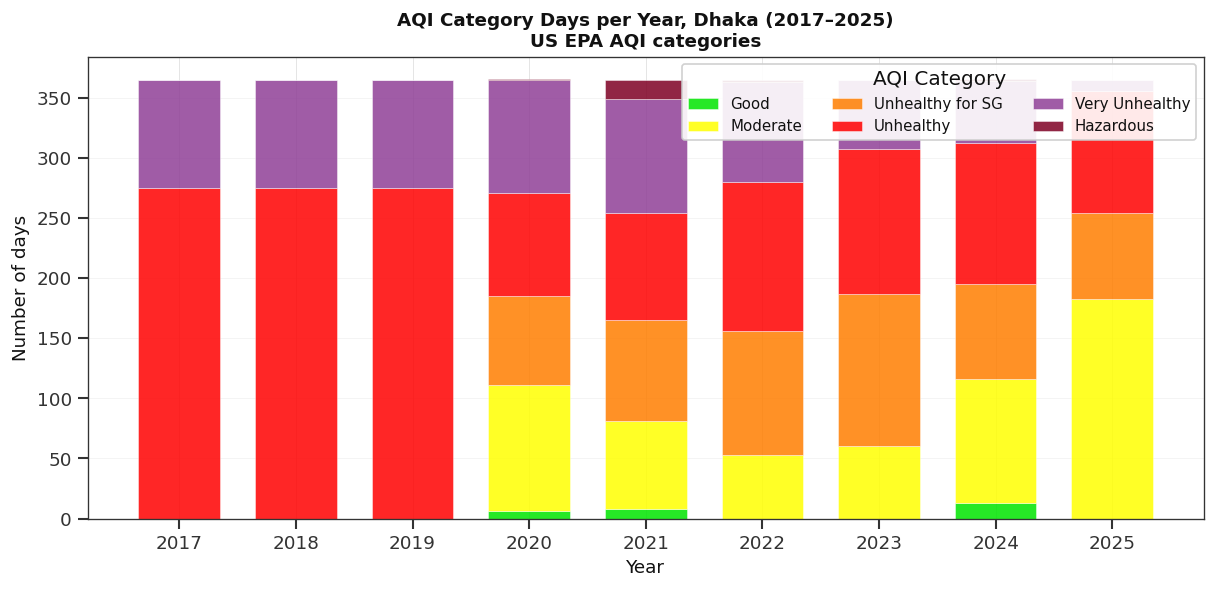

Saved → figures/analysis_fig09_aqi_category_days.png

AQI category % per year:


aqi_cat,Good,Moderate,Unhealthy for SG,Unhealthy,Very Unhealthy,Hazardous
year,,,,,,
2017,0.0,0.0,0.0,75.3,24.7,0.0
2018,0.0,0.0,0.0,75.3,24.7,0.0
2019,0.0,0.0,0.0,75.3,24.7,0.0
2020,1.6,28.7,20.2,23.5,25.7,0.3
2021,2.2,20.0,23.0,24.4,26.0,4.4
2022,0.0,14.5,28.2,34.0,22.7,0.5
2023,0.0,16.4,34.8,32.9,15.9,0.0
2024,3.6,28.1,21.6,32.0,14.2,0.5
2025,0.0,50.1,19.5,27.9,2.5,0.0


In [14]:
# ── Figure 9: AQI category days per year (stacked bar) ───────────────────────
CAT_ORDER  = ['Good', 'Moderate', 'Unhealthy for SG', 'Unhealthy', 'Very Unhealthy', 'Hazardous']
CAT_COLORS = ['#00e400', '#ffff00', '#ff7e00', '#ff0000', '#8f3f97', '#7e0023']

d_cats = daily[(daily['year'] >= 2017) & (daily['year'] <= 2025)].copy()
cat_counts = d_cats.groupby(['year','aqi_cat']).size().unstack(fill_value=0)

# Ensure all categories present
for cat in CAT_ORDER:
    if cat not in cat_counts.columns:
        cat_counts[cat] = 0
cat_counts = cat_counts[CAT_ORDER]

fig, ax = plt.subplots(figsize=(12, 5))

bottoms = np.zeros(len(cat_counts))
years   = cat_counts.index.values

for cat, color in zip(CAT_ORDER, CAT_COLORS):
    vals = cat_counts[cat].values
    ax.bar(years, vals, bottom=bottoms, color=color, alpha=0.85,
           label=cat, width=0.7, edgecolor='white', linewidth=0.3)
    bottoms += vals

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Number of days', fontsize=11)
ax.set_title('AQI Category Days per Year, Dhaka (2017–2025)\n'
             'US EPA AQI categories', fontsize=11)
ax.set_xticks(years)
ax.legend(fontsize=9, ncol=3, loc='upper right', title='AQI Category')
ax.grid(axis='y', linewidth=0.4, alpha=0.5)

display(fig)
save_fig(fig, 'analysis_fig09_aqi_category_days')
plt.close(fig)

# Print category fractions
cat_pct = cat_counts.div(cat_counts.sum(axis=1), axis=0) * 100
print('\nAQI category % per year:')
display(cat_pct.round(1))

---
## § 9 — Socioeconomic Context (Figure 10)

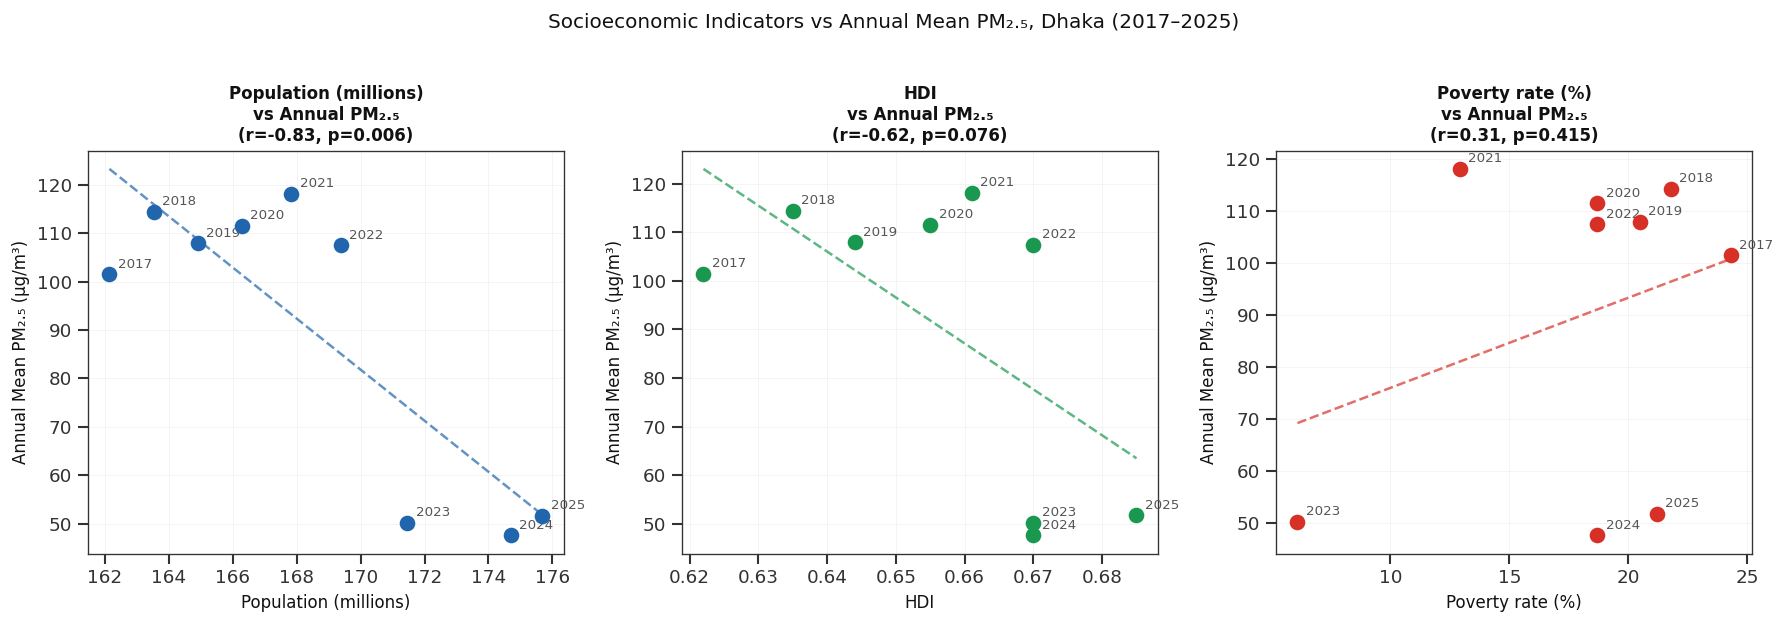

Saved → figures/analysis_fig10_socioeconomic.png


In [15]:
# ── Figure 10: Socioeconomic indicators vs annual PM2.5 ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

annual_pm25_yr = daily[(daily['year'] <= 2025) & daily['pm25'].notna()].groupby('year')['pm25'].mean()
socio_pm = annual_socio.set_index('year').join(annual_pm25_yr.rename('pm25_annual'))

panels = [
    ('population_total', 'Population (millions)', lambda x: x/1e6, '#2166ac', False),
    ('hdi',              'HDI',                    lambda x: x,     '#1a9850', False),
    ('poverty_rate_pct', 'Poverty rate (%)',        lambda x: x,     '#d73027', True),
]

for ax, (col, ylabel, xform, color, invert) in zip(axes, panels):
    x = socio_pm[col].apply(xform)
    y = socio_pm['pm25_annual']
    years_s = socio_pm.index

    ax.scatter(x, y, color=color, s=70, zorder=5)
    for yr, xi, yi in zip(years_s, x, y):
        ax.annotate(str(yr), (xi, yi), textcoords='offset points',
                    xytext=(5, 4), fontsize=8, color='#555')

    # Trend line
    if len(x.dropna()) > 3:
        valid = x.notna() & y.notna()
        m, b, r, p, _ = stats.linregress(x[valid], y[valid])
        xl = np.linspace(x.min(), x.max(), 100)
        ax.plot(xl, m*xl + b, color=color, linestyle='--', linewidth=1.5, alpha=0.7)
        ax.set_title(f'{ylabel}\nvs Annual PM₂.₅\n(r={r:.2f}, p={p:.3f})', fontsize=10)
    else:
        ax.set_title(f'{ylabel} vs Annual PM₂.₅', fontsize=10)

    ax.set_xlabel(ylabel, fontsize=10)
    ax.set_ylabel('Annual Mean PM₂.₅ (µg/m³)', fontsize=10)
    ax.grid(linewidth=0.4, alpha=0.5)

plt.suptitle('Socioeconomic Indicators vs Annual Mean PM₂.₅, Dhaka (2017–2025)',
             fontsize=12, y=1.03)
plt.tight_layout()
display(fig)
save_fig(fig, 'analysis_fig10_socioeconomic')
plt.close(fig)


---
## § 10 — Summary Statistics for Paper (Tables)

These tables consolidate key numbers cited in the paper narrative.

In [16]:
# ── Table 1: Annual mean PM2.5 summary with WHO multiples ────────────────────
ann = daily[(daily['year'] <= 2025) & daily['pm25'].notna()].groupby('year').agg(
    n_days   = ('pm25', 'count'),
    mean     = ('pm25', 'mean'),
    median   = ('pm25', 'median'),
    p95      = ('pm25', lambda x: x.quantile(0.95)),
    days_exc_who = ('pm25', lambda x: (x > WHO_PM25_24HR).sum()),
    days_exc_bgd = ('pm25', lambda x: (x > BGD_PM25_24HR).sum()),
).reset_index()
ann['who_multiple']  = (ann['mean'] / WHO_PM25_ANNUAL).round(1)
ann['bgd_exc_pct']   = (ann['days_exc_bgd'] / ann['n_days'] * 100).round(1)
ann['who_exc_pct']   = (ann['days_exc_who'] / ann['n_days'] * 100).round(1)

print('Table 1: Annual PM₂.₅ Summary')
display(ann.to_string(index=False))

Table 1: Annual PM₂.₅ Summary


' year  n_days       mean   median       p95  days_exc_who  days_exc_bgd  who_multiple  bgd_exc_pct  who_exc_pct\n 2017     365 101.493205  82.8400 206.31600           365           223          20.3         61.1        100.0\n 2018     365 114.332055  96.2980 227.80200           365           238          22.9         65.2        100.0\n 2019     365 107.884627  91.1150 226.63160           365           240          21.6         65.8        100.0\n 2020     366 111.521109  92.8245 243.27725           366           229          22.3         62.6        100.0\n 2021     365 118.126129 100.5420 256.24360           365           229          23.6         62.7        100.0\n 2022     365 107.460575  84.3320 240.79080           365           226          21.5         61.9        100.0\n 2023     365  50.231781  51.3600 109.95000           334            59          10.0         16.2         91.5\n 2024     366  47.677486  48.4500  86.71000           304           121           9.5         3

In [17]:
# ── Table 2: Seasonal summary (all years combined) ───────────────────────────
seas = daily[daily['pm25'].notna()].groupby('season', observed=True).agg(
    n_days   = ('pm25', 'count'),
    pm25_mean   = ('pm25', 'mean'),
    pm25_median = ('pm25', 'median'),
    pm25_p5     = ('pm25', lambda x: x.quantile(0.05)),
    pm25_p95    = ('pm25', lambda x: x.quantile(0.95)),
    aqi_mean    = ('aqi',  'mean'),
).reset_index()

print('Table 2: Seasonal PM₂.₅ Summary (all years)')
display(seas.round(1).to_string(index=False))

Table 2: Seasonal PM₂.₅ Summary (all years)


'      season  n_days  pm25_mean  pm25_median  pm25_p5  pm25_p95  aqi_mean\n      Winter     812      160.5        170.2     70.4     263.7     221.1\n Pre-monsoon     828       78.6         64.6     32.8     156.8     161.1\n     Monsoon    1098       36.9         31.8     12.5      76.7     126.0\nPost-monsoon     549      109.5         98.4     48.4     209.0     163.7'

In [18]:
# ── Table 3: COVID lockdown quantitative impact ───────────────────────────────
periods = [
    ('Pre-lockdown',  daily[(daily['date'] >= '2018-01-01') & (daily['date'] < LOCKDOWN_START)]),
    ('Lockdown',      daily[(daily['date'] >= LOCKDOWN_START) & (daily['date'] <= LOCKDOWN_END)]),
    ('Post-lockdown', daily[(daily['date'] > LOCKDOWN_END) & (daily['date'] <= '2022-12-31')]),
]

rows = []
for name, grp in periods:
    g = grp[grp['pm25'].notna()]
    rows.append(dict(
        Period  = name,
        n_days  = len(g),
        PM25_mean   = round(g['pm25'].mean(), 1),
        PM25_median = round(g['pm25'].median(), 1),
        AQI_mean    = round(g['aqi'].mean(), 1),
    ))
covid_tbl = pd.DataFrame(rows)
pre_mean  = covid_tbl.loc[0,'PM25_mean']
lock_mean = covid_tbl.loc[1,'PM25_mean']
covid_tbl['vs_pre_pct'] = ((covid_tbl['PM25_mean'] - pre_mean) / pre_mean * 100).round(1)

print('Table 3: COVID Lockdown PM₂.₅ Impact')
display(covid_tbl.to_string(index=False))

Table 3: COVID Lockdown PM₂.₅ Impact


'       Period  n_days  PM25_mean  PM25_median  AQI_mean  vs_pre_pct\n Pre-lockdown     815      118.7        106.3     205.2         0.0\n     Lockdown     159       53.6         43.4     115.2       -54.8\nPost-lockdown     852      116.2         98.6     160.5        -2.1'

In [19]:
# ── Figures generated in this notebook ───────────────────────────────────────
import os
figs = sorted([f for f in os.listdir('figures') if f.startswith('analysis_')])
print(f'Analysis figures saved ({len(figs)} total):')
for f in figs:
    print(f'  figures/{f}')

Analysis figures saved (10 total):
  figures/analysis_fig01_daily_time_series.png
  figures/analysis_fig02_monthly_pm25_boxplot.png
  figures/analysis_fig03_pm25_heatmap.png
  figures/analysis_fig04_pm25_exceedance.png
  figures/analysis_fig05_annual_pm25_vs_standards.png
  figures/analysis_fig06_cams_seasonal_cycle.png
  figures/analysis_fig07_pollutant_correlation.png
  figures/analysis_fig08_covid_daily.png
  figures/analysis_fig09_aqi_category_days.png
  figures/analysis_fig10_socioeconomic.png


---
## § 11 — STL Seasonal Decomposition (Figures 11–12)

STL (Seasonal-Trend decomposition using Loess) applied to **daily PM₂.₅** 
identifies three additive components:
- **Trend** — long-run direction after smoothing out seasonality
- **Seasonal** — recurring annual cycle
- **Residual** — irregular events (pollution spikes, COVID dip, etc.)

A second STL is applied to **monthly mean PM₂.₅** for a cleaner long-run trend view.


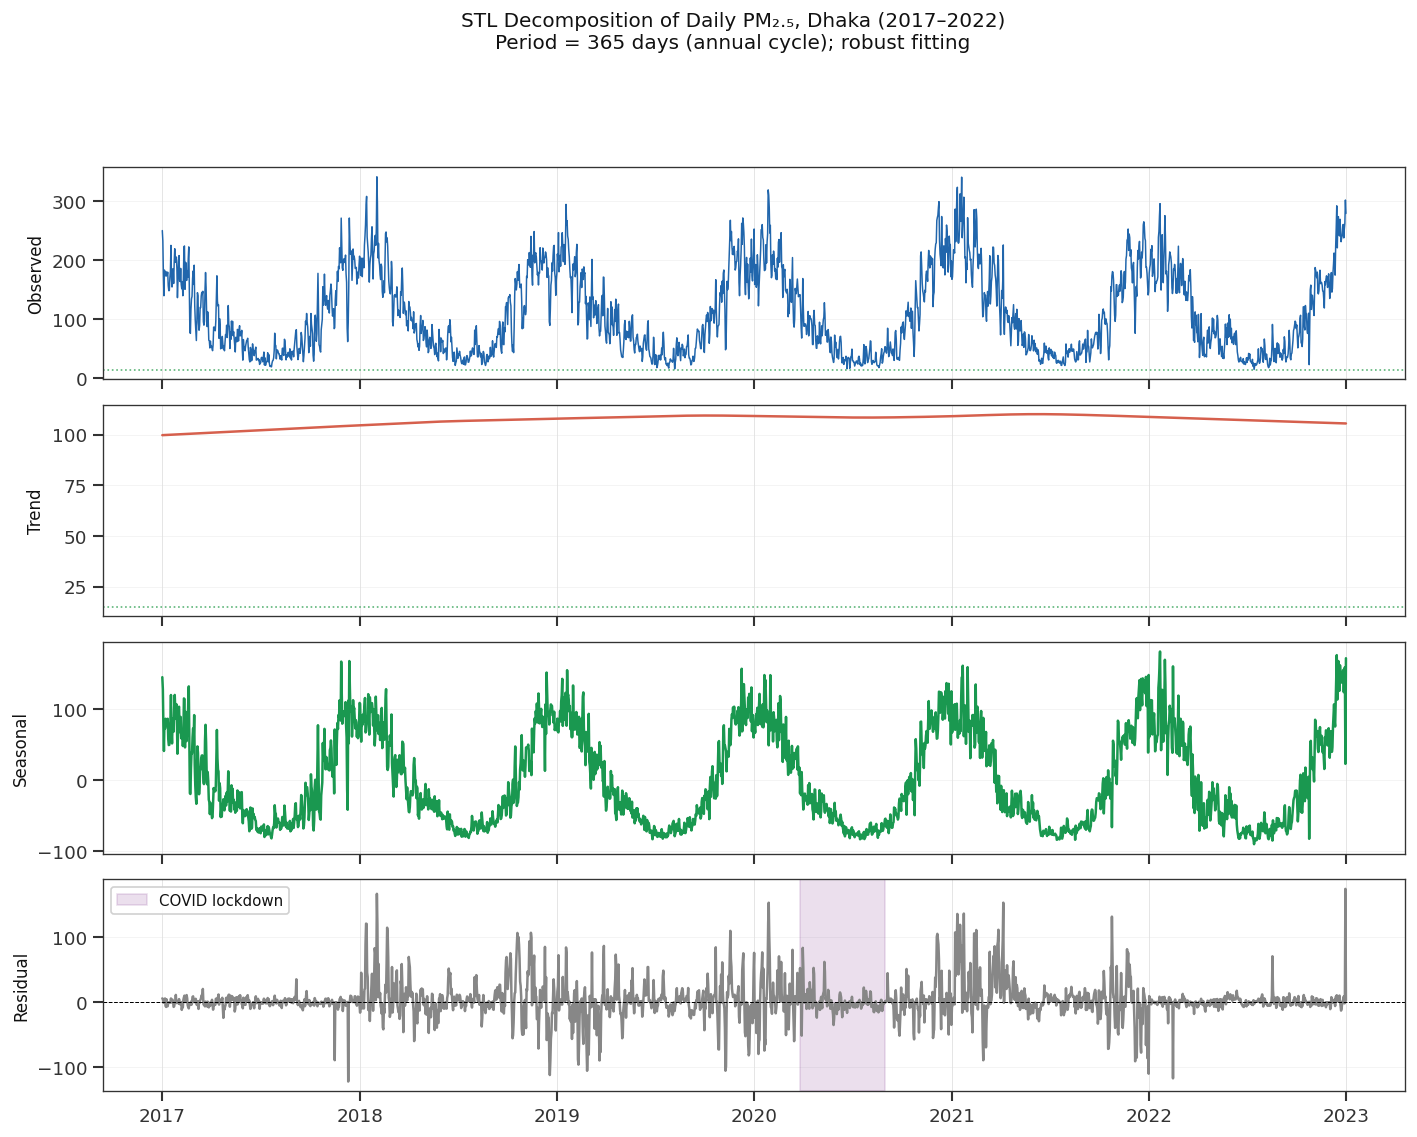

Saved → figures/analysis_fig11_stl_daily_pm25.png


In [20]:
from statsmodels.tsa.seasonal import STL
from IPython.display import display

# Use CAMS period (2017-2022) for fully-populated daily series
pm25_cams = daily[(daily['date'] >= '2017-01-01') & (daily['date'] <= '2022-12-31')].set_index('date')['pm25']
pm25_cams = pm25_cams.asfreq('D').interpolate('linear')  # fill rare gaps

stl = STL(pm25_cams, period=365, robust=True)
result = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
fig.subplots_adjust(hspace=0.12)

components = [
    (pm25_cams,         'Observed',   '#2166ac'),
    (result.trend,      'Trend',      '#d6604d'),
    (result.seasonal,   'Seasonal',   '#1a9850'),
    (result.resid,      'Residual',   '#878787'),
]

for ax, (series, label, color) in zip(axes, components):
    ax.plot(series.index, series.values, color=color, linewidth=0.9 if label=='Observed' else 1.5)
    ax.set_ylabel(label, fontsize=10)
    ax.grid(axis='y', linewidth=0.4, alpha=0.5)
    if label == 'Residual':
        ax.axhline(0, color='black', linewidth=0.6, linestyle='--')
    if label in ('Observed','Trend'):
        ax.axhline(15, color='#1a9641', linestyle=':', linewidth=1.0, alpha=0.7)

# Annotate COVID on residual
axes[3].axvspan(
    pd.Timestamp('2020-03-26'), pd.Timestamp('2020-08-31'),
    color='#7b2d8b', alpha=0.15, label='COVID lockdown'
)
axes[3].legend(fontsize=9)

axes[0].xaxis.set_major_locator(mdates.YearLocator())
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

fig.suptitle('STL Decomposition of Daily PM₂.₅, Dhaka (2017–2022)\n'
             'Period = 365 days (annual cycle); robust fitting', fontsize=12, y=1.01)
display(fig)
save_fig(fig, 'analysis_fig11_stl_daily_pm25')
plt.close(fig)


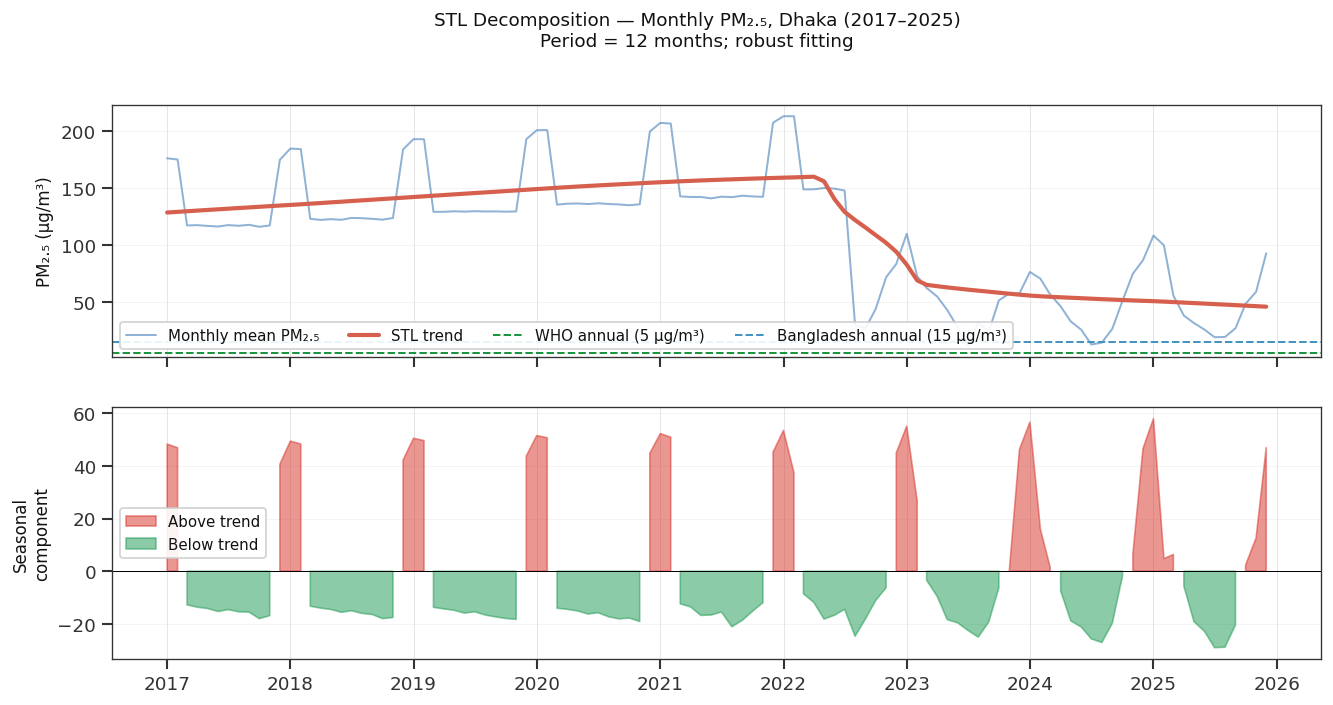

Saved → figures/analysis_fig12_stl_monthly_pm25.png
STL trend slope: -1.070 µg/m³/month  (-12.84 µg/m³/year)
Over full period: -115.6 µg/m³ total change


In [21]:
# ── Figure 12: Monthly STL trend (full 2017-2025 monthly series) ─────────────
monthly_pm25 = monthly.set_index('month_start')['pm25_mean'].asfreq('MS')

stl_m = STL(monthly_pm25, period=12, robust=True)
res_m = stl_m.fit()

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

# Panel A: observed + trend
axes[0].plot(monthly_pm25.index, monthly_pm25.values, color='#2166ac',
             alpha=0.5, linewidth=1.2, label='Monthly mean PM₂.₅')
axes[0].plot(res_m.trend.index, res_m.trend.values, color='#d6604d',
             linewidth=2.5, label='STL trend')
axes[0].axhline(WHO_PM25_ANNUAL, color='#1a9641', linestyle='--', linewidth=1.2,
                label=f'WHO annual ({WHO_PM25_ANNUAL} µg/m³)')
axes[0].axhline(BGD_PM25_ANNUAL, color='#4393c3', linestyle='--', linewidth=1.2,
                label=f'Bangladesh annual ({BGD_PM25_ANNUAL} µg/m³)')
axes[0].set_ylabel('PM₂.₅ (µg/m³)', fontsize=10)
axes[0].legend(fontsize=9, ncol=4)
axes[0].grid(axis='y', linewidth=0.4, alpha=0.5)

# Panel B: seasonal component
axes[1].fill_between(res_m.seasonal.index, res_m.seasonal.values, 0,
                     where=res_m.seasonal.values > 0, color='#d73027', alpha=0.5, label='Above trend')
axes[1].fill_between(res_m.seasonal.index, res_m.seasonal.values, 0,
                     where=res_m.seasonal.values < 0, color='#1a9850', alpha=0.5, label='Below trend')
axes[1].axhline(0, color='black', linewidth=0.6)
axes[1].set_ylabel('Seasonal\ncomponent', fontsize=10)
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', linewidth=0.4, alpha=0.5)

axes[1].xaxis.set_major_locator(mdates.YearLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

fig.suptitle('STL Decomposition — Monthly PM₂.₅, Dhaka (2017–2025)\n'
             'Period = 12 months; robust fitting', fontsize=11, y=1.01)
display(fig)
save_fig(fig, 'analysis_fig12_stl_monthly_pm25')
plt.close(fig)

# Trend slope from STL
from scipy.stats import linregress
t = np.arange(len(res_m.trend))
slope, intercept, r, p, _ = linregress(t, res_m.trend.values)
print(f'STL trend slope: {slope:.3f} µg/m³/month  ({slope*12:.2f} µg/m³/year)')
print(f'Over full period: {slope * len(t):.1f} µg/m³ total change')


---
## § 12 — Forecast 2026–2030 with NAQMP Scenarios (Figures 13–14)

The **Bangladesh National Air Quality Management Plan (NAQMP) 2024–2030** sets two targets:
- **Nationwide**: reduce annual mean PM₂.₅ by **15 µg/m³** from the 2024 baseline
- **Greater Dhaka Area (GDA)**: reduce by **30 µg/m³** from the 2024 baseline

Three forecast scenarios are built on the monthly PM₂.₅ series (2017–2025):

| Scenario | Description |
|---|---|
| **BAU** | Business-as-usual — continue historical trend (ETS + linear) |
| **NAQMP Nationwide** | Linear decline of 15 µg/m³ from 2024 baseline by 2030 |
| **NAQMP Dhaka (GDA)** | Linear decline of 30 µg/m³ from 2024 baseline by 2030 |

> *Baseline year 2024 annual mean PM₂.₅ used as the NAQMP reference point.*


In [22]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.linear_model import LinearRegression
import warnings; warnings.filterwarnings('ignore')

# ── Monthly PM2.5 series (2017-2025) ─────────────────────────────────────────
pm25_monthly = monthly.set_index('month_start')['pm25_mean'].asfreq('MS')
pm25_train   = pm25_monthly  # use full series for production forecast

# ── Future date index (Jan 2026 – Dec 2030) ───────────────────────────────────
future_index = pd.date_range('2026-01-01', '2030-12-01', freq='MS')
n_future     = len(future_index)

# ── 1. ETS (Holt-Winters additive trend + multiplicative seasonality) ─────────
ets = ExponentialSmoothing(
    pm25_train, trend='add', seasonal='add', seasonal_periods=12,
    initialization_method='estimated'
).fit(optimized=True)
bau_ets = ets.forecast(n_future)

# ── 2. SARIMA (1,1,1)(1,1,1)[12] as second BAU ───────────────────────────────
sarima = SARIMAX(pm25_train, order=(1,1,1), seasonal_order=(1,1,1,12)).fit(disp=False)
bau_sarima = sarima.forecast(n_future)

# ── Ensemble BAU = mean of ETS + SARIMA ───────────────────────────────────────
bau_ensemble = pd.Series(
    (bau_ets.values + bau_sarima.values) / 2,
    index=future_index
)

# ── 3. NAQMP Scenarios (monthly linear interpolation from 2024 baseline to target)
baseline_2024 = pm25_monthly[pm25_monthly.index.year == 2024].mean()
target_nationwide = baseline_2024 - 15   # NAQMP nationwide target
target_gda        = baseline_2024 - 30   # NAQMP Greater Dhaka target

print(f'2024 baseline annual mean PM2.5 : {baseline_2024:.1f} µg/m³')
print(f'NAQMP Nationwide target (2030)  : {target_nationwide:.1f} µg/m³')
print(f'NAQMP Dhaka GDA target (2030)   : {target_gda:.1f} µg/m³')
print(f'WHO annual guideline            :  {WHO_PM25_ANNUAL:.1f} µg/m³')
print()

# Interpolate from Jan 2026 start-of-month seasonally-adjusted baseline
# to annual target by Dec 2030 (apply seasonal pattern on top)
seasonal_pattern = monthly.groupby('month')['pm25_mean'].mean()
annual_mean_pattern = seasonal_pattern.mean()
seasonal_factors    = seasonal_pattern / annual_mean_pattern  # ratio by month

def make_scenario(annual_start, annual_end, idx):
    years  = idx.year + idx.month / 12 - 2025.5
    annual_means = annual_start + (annual_end - annual_start) * years / 5.5
    return pd.Series(
        [am * seasonal_factors[m] for am, m in zip(annual_means, idx.month)],
        index=idx
    )

scenario_nationwide = make_scenario(baseline_2024, target_nationwide, future_index)
scenario_gda        = make_scenario(baseline_2024, target_gda,        future_index)

print('Forecast comparison at 2030-12:')
print(f'  BAU ensemble : {bau_ensemble.iloc[-1]:.1f} µg/m³')
print(f'  NAQMP nation : {scenario_nationwide.iloc[-1]:.1f} µg/m³')
print(f'  NAQMP GDA    : {scenario_gda.iloc[-1]:.1f} µg/m³')


2024 baseline annual mean PM2.5 : 47.8 µg/m³
NAQMP Nationwide target (2030)  : 32.8 µg/m³
NAQMP Dhaka GDA target (2030)   : 17.8 µg/m³
WHO annual guideline            :  5.0 µg/m³

Forecast comparison at 2030-12:
  BAU ensemble : 53.4 µg/m³
  NAQMP nation : 42.1 µg/m³
  NAQMP GDA    : 22.8 µg/m³


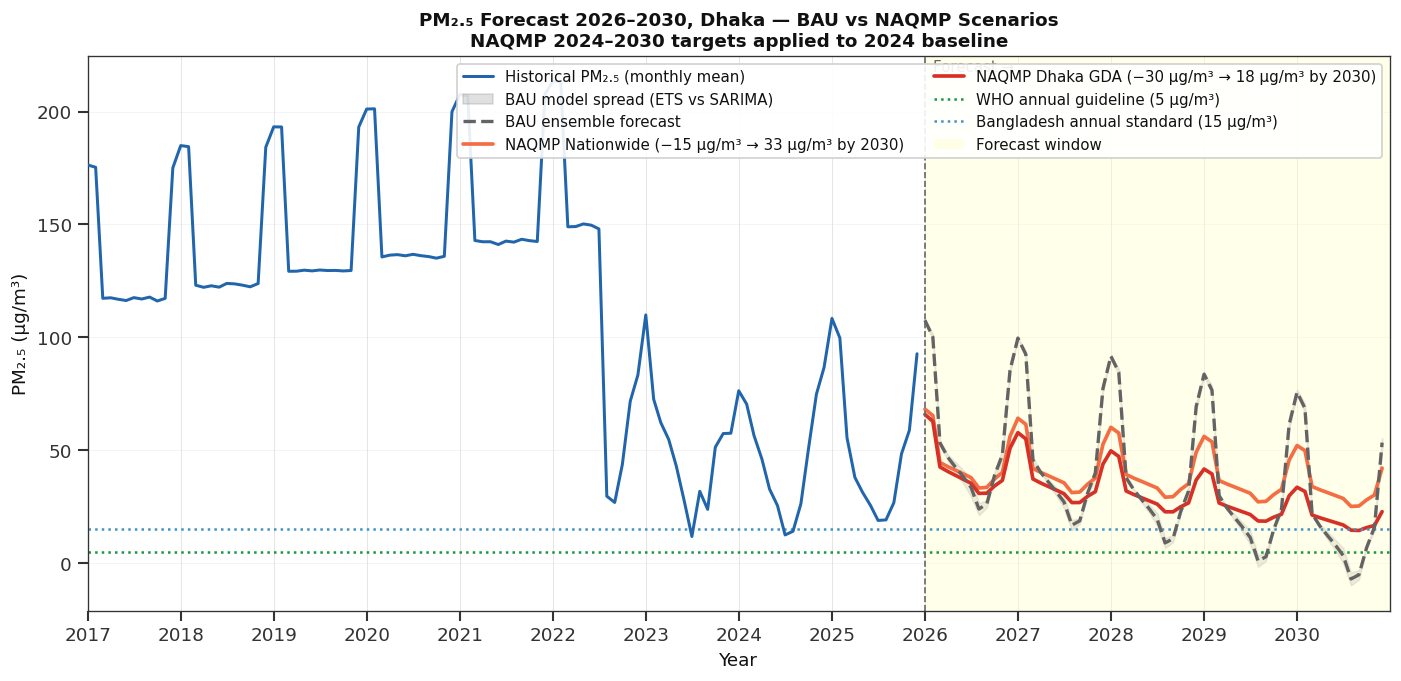

Saved → figures/analysis_fig13_forecast_2026_2030.png


In [23]:
# ── Figure 13: Forecast 2026-2030 scenarios ───────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

# Historical
ax.plot(pm25_monthly.index, pm25_monthly.values,
        color='#2166ac', linewidth=1.8, label='Historical PM₂.₅ (monthly mean)', zorder=4)

# ETS & SARIMA individual BAU (shaded as uncertainty)
ax.fill_between(future_index,
                np.minimum(bau_ets.values, bau_sarima.values),
                np.maximum(bau_ets.values, bau_sarima.values),
                color='#878787', alpha=0.25, label='BAU model spread (ETS vs SARIMA)')

# BAU ensemble
ax.plot(future_index, bau_ensemble.values,
        color='#636363', linewidth=2.0, linestyle='--', label='BAU ensemble forecast', zorder=3)

# NAQMP scenarios
ax.plot(future_index, scenario_nationwide.values,
        color='#f46d43', linewidth=2.2, linestyle='-',
        label=f'NAQMP Nationwide (−15 µg/m³ → {target_nationwide:.0f} µg/m³ by 2030)')
ax.plot(future_index, scenario_gda.values,
        color='#d73027', linewidth=2.2, linestyle='-',
        label=f'NAQMP Dhaka GDA (−30 µg/m³ → {target_gda:.0f} µg/m³ by 2030)')

# Reference lines
ax.axhline(WHO_PM25_ANNUAL,  color='#1a9641', linestyle=':', linewidth=1.5,
           label=f'WHO annual guideline ({WHO_PM25_ANNUAL} µg/m³)')
ax.axhline(BGD_PM25_ANNUAL,  color='#4393c3', linestyle=':', linewidth=1.5,
           label=f'Bangladesh annual standard ({BGD_PM25_ANNUAL} µg/m³)')

# Forecast window shading
ax.axvspan(pd.Timestamp('2026-01-01'), pd.Timestamp('2030-12-31'),
           color='#ffffcc', alpha=0.4, linewidth=0, label='Forecast window')
ax.axvline(pd.Timestamp('2026-01-01'), color='#666', linewidth=1.0, linestyle='--')
ax.text(pd.Timestamp('2026-02-01'), ax.get_ylim()[1] * 0.97, 'Forecast →',
        fontsize=9, color='#666')

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('PM₂.₅ (µg/m³)', fontsize=11)
ax.set_title('PM₂.₅ Forecast 2026–2030, Dhaka — BAU vs NAQMP Scenarios\n'
             'NAQMP 2024–2030 targets applied to 2024 baseline', fontsize=11)
ax.legend(fontsize=9, ncol=2, loc='upper right')
ax.grid(axis='y', linewidth=0.4, alpha=0.5)
ax.set_xlim(pd.Timestamp('2017-01-01'), pd.Timestamp('2030-12-31'))

display(fig)
save_fig(fig, 'analysis_fig13_forecast_2026_2030')
plt.close(fig)


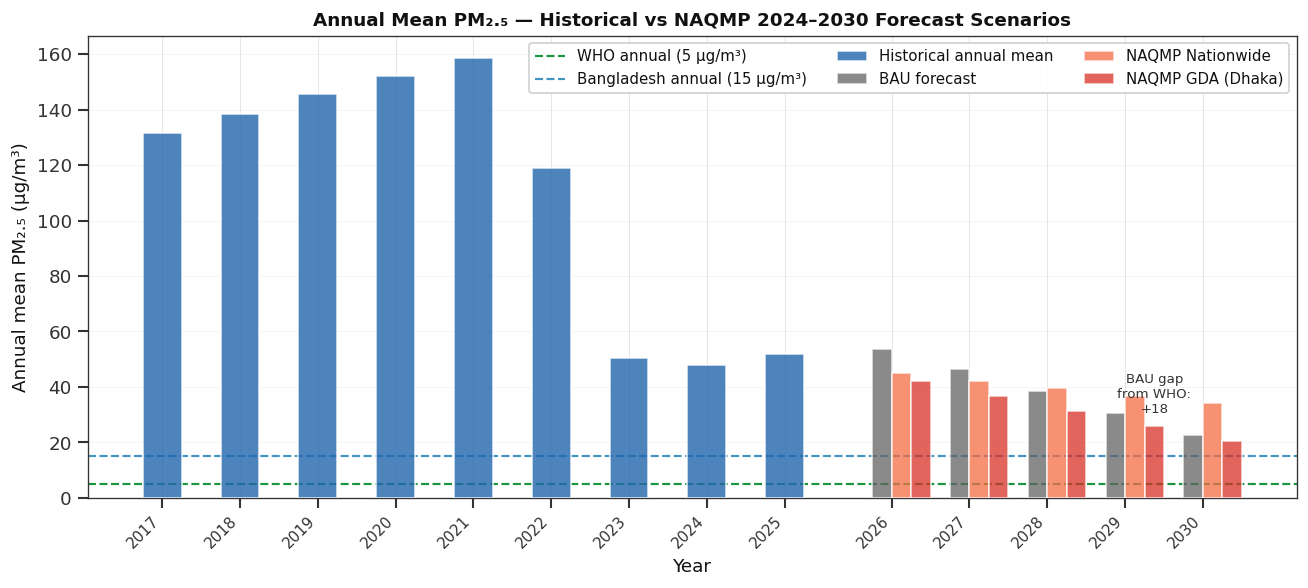

Saved → figures/analysis_fig14_annual_forecast_bar.png
2030 projected annual mean PM₂.₅:
  BAU ensemble     : 22.5 µg/m³  (4.5× WHO annual)
  NAQMP Nationwide : 34.1 µg/m³  (6.8× WHO annual)
  NAQMP Dhaka GDA  : 20.4 µg/m³  (4.1× WHO annual)
  WHO annual guide : 5 µg/m³


In [24]:
# ── Figure 14: Annual PM2.5 forecast bar chart + NAQMP target gap ─────────────
fig, ax = plt.subplots(figsize=(13, 5))

# Historical annual means
hist_ann = pm25_monthly.resample('YE').mean()
hist_ann.index = hist_ann.index.year

# Forecast annual means
bau_ann  = bau_ensemble.resample('YE').mean()
bau_ann.index = bau_ann.index.year
naqmp_n  = scenario_nationwide.resample('YE').mean()
naqmp_n.index = naqmp_n.index.year
naqmp_g  = scenario_gda.resample('YE').mean()
naqmp_g.index = naqmp_g.index.year

width = 0.25
hist_years = hist_ann.index.values
fc_years   = bau_ann.index.values

ax.bar(hist_years - width, hist_ann.values, width=width*2, color='#2166ac',
       alpha=0.8, label='Historical annual mean', zorder=3)
ax.bar(fc_years,            bau_ann.values,  width=width,   color='#636363',
       alpha=0.75, label='BAU forecast', zorder=3)
ax.bar(fc_years + width,    naqmp_n.values,  width=width,   color='#f46d43',
       alpha=0.75, label='NAQMP Nationwide', zorder=3)
ax.bar(fc_years + width*2,  naqmp_g.values,  width=width,   color='#d73027',
       alpha=0.75, label='NAQMP GDA (Dhaka)', zorder=3)

ax.axhline(WHO_PM25_ANNUAL,  color='#1a9641', linestyle='--', linewidth=1.3,
           label=f'WHO annual ({WHO_PM25_ANNUAL} µg/m³)')
ax.axhline(BGD_PM25_ANNUAL,  color='#4393c3', linestyle='--', linewidth=1.3,
           label=f'Bangladesh annual ({BGD_PM25_ANNUAL} µg/m³)')

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Annual mean PM₂.₅ (µg/m³)', fontsize=11)
ax.set_title('Annual Mean PM₂.₅ — Historical vs NAQMP 2024–2030 Forecast Scenarios',
             fontsize=11)
ax.set_xticks(list(hist_years - width) + list(fc_years + width/2))
ax.set_xticklabels([str(y) for y in hist_years] + [str(y) for y in fc_years],
                   rotation=45, ha='right', fontsize=9)
ax.legend(fontsize=9, ncol=3)
ax.grid(axis='y', linewidth=0.4, alpha=0.5)

# Gap annotations for 2030
gap_bau   = bau_ann.iloc[-1]  - WHO_PM25_ANNUAL
gap_naqmp = naqmp_g.iloc[-1]  - WHO_PM25_ANNUAL
ax.annotate(f'BAU gap\nfrom WHO:\n+{gap_bau:.0f}',
            xy=(fc_years[-1], bau_ann.iloc[-1]),
            xytext=(fc_years[-1] - 0.5, bau_ann.iloc[-1] + 8),
            fontsize=8, color='#333', ha='center')

display(fig)
save_fig(fig, 'analysis_fig14_annual_forecast_bar')
plt.close(fig)

# Print 2030 summary
print('2030 projected annual mean PM₂.₅:')
print(f'  BAU ensemble     : {bau_ann.iloc[-1]:.1f} µg/m³  ({bau_ann.iloc[-1]/WHO_PM25_ANNUAL:.1f}× WHO annual)')
print(f'  NAQMP Nationwide : {naqmp_n.iloc[-1]:.1f} µg/m³  ({naqmp_n.iloc[-1]/WHO_PM25_ANNUAL:.1f}× WHO annual)')
print(f'  NAQMP Dhaka GDA  : {naqmp_g.iloc[-1]:.1f} µg/m³  ({naqmp_g.iloc[-1]/WHO_PM25_ANNUAL:.1f}× WHO annual)')
print(f'  WHO annual guide : {WHO_PM25_ANNUAL:.0f} µg/m³')


---
## § 13 — Additional Analyses

### Rolling Annual Mean (12-month moving average)
Smooths out seasonality to show the long-run trend clearly — useful for paper narrative.


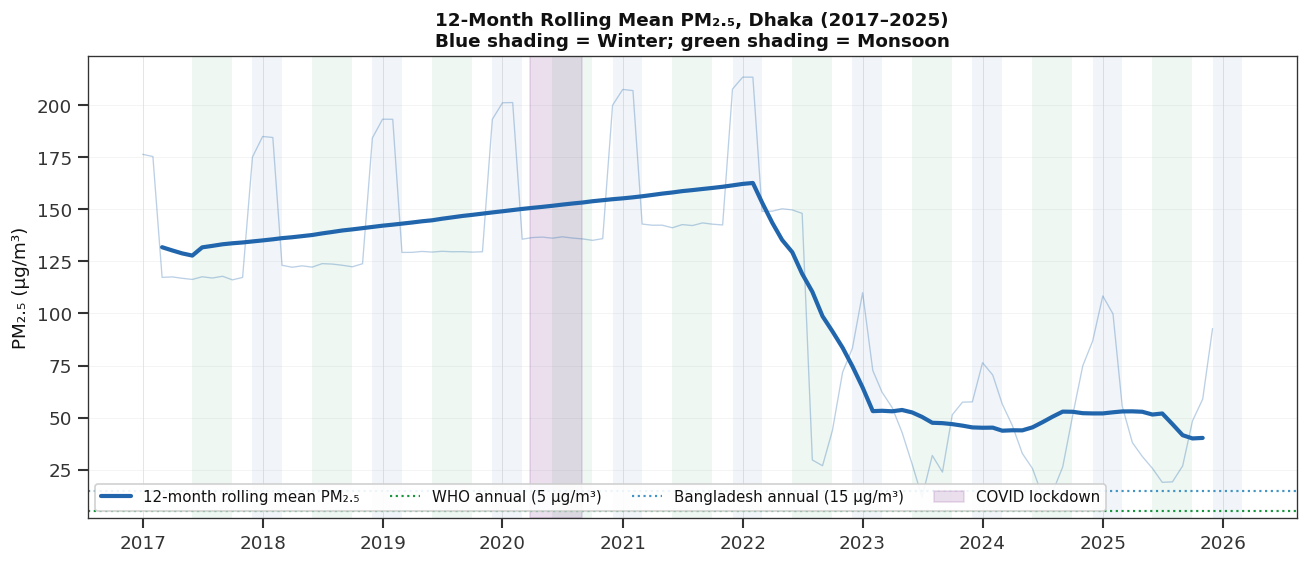

Saved → figures/analysis_fig15_rolling_annual_mean.png


In [25]:
# ── Figure 15: Rolling 12-month mean + trend bands ────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))

pm25_m = pm25_monthly.copy()
roll12 = pm25_m.rolling(12, center=True, min_periods=8).mean()

ax.plot(pm25_m.index, pm25_m.values, color='#2166ac', alpha=0.3, linewidth=0.8)
ax.plot(roll12.index, roll12.values, color='#2166ac', linewidth=2.5,
        label='12-month rolling mean PM₂.₅')

# Shade seasons
for yr in range(2017, 2026):
    for (s, e, c, a) in [
        (f'{yr}-12-01', f'{yr+1}-02-28', '#4475b4', 0.07),
        (f'{yr}-06-01', f'{yr}-09-30',   '#1a9850', 0.07),
    ]:
        try:
            ax.axvspan(pd.Timestamp(s), pd.Timestamp(e), color=c, alpha=a, linewidth=0)
        except: pass

ax.axhline(WHO_PM25_ANNUAL,  color='#1a9641', linestyle=':', linewidth=1.3,
           label=f'WHO annual ({WHO_PM25_ANNUAL} µg/m³)')
ax.axhline(BGD_PM25_ANNUAL,  color='#4393c3', linestyle=':', linewidth=1.3,
           label=f'Bangladesh annual ({BGD_PM25_ANNUAL} µg/m³)')

# COVID dip
ax.axvspan(pd.Timestamp('2020-03-26'), pd.Timestamp('2020-08-31'),
           color='#7b2d8b', alpha=0.15, label='COVID lockdown')

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_ylabel('PM₂.₅ (µg/m³)', fontsize=11)
ax.set_title('12-Month Rolling Mean PM₂.₅, Dhaka (2017–2025)\n'
             'Blue shading = Winter; green shading = Monsoon', fontsize=11)
ax.legend(fontsize=9, ncol=4)
ax.grid(axis='y', linewidth=0.4, alpha=0.5)

display(fig)
save_fig(fig, 'analysis_fig15_rolling_annual_mean')
plt.close(fig)


In [26]:
import os
figs = sorted([f for f in os.listdir('figures') if f.startswith('analysis_')])
print(f'All analysis figures ({len(figs)} total):')
for f in figs:
    size_kb = os.path.getsize(f'figures/{f}') // 1024
    print(f'  figures/{f}  ({size_kb} KB)')


All analysis figures (15 total):
  figures/analysis_fig01_daily_time_series.png  (623 KB)
  figures/analysis_fig02_monthly_pm25_boxplot.png  (172 KB)
  figures/analysis_fig03_pm25_heatmap.png  (273 KB)
  figures/analysis_fig04_pm25_exceedance.png  (172 KB)
  figures/analysis_fig05_annual_pm25_vs_standards.png  (162 KB)
  figures/analysis_fig06_cams_seasonal_cycle.png  (706 KB)
  figures/analysis_fig07_pollutant_correlation.png  (151 KB)
  figures/analysis_fig08_covid_daily.png  (521 KB)
  figures/analysis_fig09_aqi_category_days.png  (148 KB)
  figures/analysis_fig10_socioeconomic.png  (333 KB)
  figures/analysis_fig11_stl_daily_pm25.png  (669 KB)
  figures/analysis_fig12_stl_monthly_pm25.png  (319 KB)
  figures/analysis_fig13_forecast_2026_2030.png  (468 KB)
  figures/analysis_fig14_annual_forecast_bar.png  (184 KB)
  figures/analysis_fig15_rolling_annual_mean.png  (269 KB)
